# 01 — vehicles.csv の全体像をつかむ

Colab と同じで、上のセルから順に **Shift + Enter** で実行していきます。

違うのは次の3点です。

1. **`!pip install` は書きません。** 必要なライブラリは `.venv` に入れてあります
2. **ファイルは最初からそこにあります。** アップロードも Drive のマウントも不要
3. **保存すれば消えません。** セッション切れでやり直しになることはありません

## 0. セットアップ（まず最初にこのセルを実行）

**このノートブックは上から順に実行してください。**
Jupyter は「実行した順」に状態が変わるので、途中のセルだけ実行すると
`NameError: name 'RAW' is not defined` のようなエラーになります。

順番がわからなくなったら、メニューの **Run → Run All Above**
（VS Code なら各セル左上の「上のセルまで実行」）で復旧できます。

In [1]:
import sys
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# --- 実行中の Python の確認 ---------------------------------------
# ここが .venv 以下でなければ、カーネルの選択を間違えています
print("Python :", sys.version.split()[0])
print("実行元 :", sys.executable)
assert ".venv" in sys.executable, (
    "カーネルが .venv になっていません。"
    "右上の『カーネルの選択』で .venv を選び直してください。"
)

# --- パスの設定 ---------------------------------------------------
# ノートブックを notebooks/ から開いてもリポジトリ直下から開いても動くようにする
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "sampledata" / "raw" / "vehicles.csv"
PROCESSED = ROOT / "sampledata" / "processed"

assert RAW.exists(), (
    f"{RAW} がありません。"
    "ターミナルで python scripts/download_data.py を実行してください。"
)

# --- グラフの設定 -------------------------------------------------
# macOS の日本語フォント（設定しないとグラフの日本語が豆腐□になる）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (8, 4)

# --- 分析用のパラメータ -------------------------------------------
# 価格の外れ値をどこで切るか。暫定値なので、根拠が固まったら変える
PRICE_MIN, PRICE_MAX = 500, 100_000

# --- DuckDB のヘルパ ----------------------------------------------
SRC = f"read_csv_auto('{RAW}', ignore_errors=true)"

def q(sql):
    """SQL を実行して DataFrame で返す。文中の {src} が CSV に置き換わる。"""
    return duckdb.sql(sql.format(src=SRC)).df()

print("データ :", RAW.name, f"({RAW.stat().st_size / 1024**3:.1f} GB)")
print("\nセットアップ完了。以降のセルを上から順に実行してください。")


Python : 3.12.14
実行元 : /Users/attuan/carprice/.venv/bin/python
データ : vehicles.csv (1.3 GB)

セットアップ完了。以降のセルを上から順に実行してください。


## 1. DuckDB で「読み込まずに」集計する

Colab では `pd.read_csv()` で全部メモリに載せていたと思います。
でもこのファイルは 1.4GB あり、pandas で全件読むと **56秒 / 6.8GB** かかります。

DuckDB は CSV を**ファイルのまま SQL で読む**ので、同じ集計が **1.3秒 / 0.22GB** で終わります。
試行錯誤する探索段階では、この差が効いてきます。

In [2]:
q("SELECT count(*) AS 行数 FROM {src}")

,行数
0,426880


### 欠損率を見る

分析の第一歩は「どの列が使えるのか」の把握です。
`count(列名)` は **NULL を数えない**ので、全体との差が欠損数になります。

In [3]:
cols = ["price", "year", "odometer", "manufacturer", "model", "condition",
        "cylinders", "fuel", "title_status", "transmission", "drive",
        "size", "type", "paint_color", "description", "image_url", "state"]

sel = ", ".join(f"100.0 * count({c}) / count(*) AS {c}" for c in cols)
missing = q(f"SELECT {sel} FROM {{src}}").T
missing.columns = ["充足率(%)"]
missing.sort_values("充足率(%)", ascending=False).round(1)

,充足率(%)
price,100.0
state,100.0
image_url,100.0
description,100.0
year,99.7
transmission,99.4
fuel,99.3
odometer,99.0
model,98.8
title_status,98.1


**読み方：** 充足率が低い列は、使うと行がごっそり減ります。
`size` のような列は欠損が多く、そのまま特徴量にすると学習データが激減します。

一方 `description` と `image_url` が9割以上あるのが、このプロジェクトにとって重要です。
unfold 構想（画像とテキストから特徴量を作る）が試せるのはこの2列があるからです。

## 2. price の外れ値を確認する

平均だけ見て判断すると事故ります。**必ず分位点を見てください。**

In [4]:
q("""
SELECT count(*) AS 件数,
       round(avg(price)) AS 平均,
       min(price) AS 最小,
       quantile_cont(price, 0.01) AS p1,
       quantile_cont(price, 0.25) AS p25,
       quantile_cont(price, 0.50) AS 中央値,
       quantile_cont(price, 0.75) AS p75,
       quantile_cont(price, 0.99) AS p99,
       max(price) AS 最大
FROM {src}
""").T.rename(columns={0: "price(USD)"})

,price(USD)
件数,4.268800e+05
平均,7.519900e+04
最小,0.000000e+00
p1,0.000000e+00
p25,5.900000e+03
中央値,1.395000e+04
p75,2.648575e+04
p99,6.699500e+04
最大,3.736929e+09


In [5]:
# price = 0 の行がどれだけあるか（売り出し価格未記入と思われる）
q("""
SELECT
  sum(CASE WHEN price = 0 THEN 1 ELSE 0 END) AS ゼロ円,
  sum(CASE WHEN price BETWEEN 1 AND 499 THEN 1 ELSE 0 END) AS "1-499ドル",
  sum(CASE WHEN price > 100000 THEN 1 ELSE 0 END) AS "10万ドル超",
  count(*) AS 全体
FROM {src}
""")

,ゼロ円,1-499ドル,10万ドル超,全体
0,32895.0,9199.0,655.0,426880


## 3. 外れ値を除いて分布を見る

ここでは `$500 〜 $100,000` に絞ります。
**この閾値は暫定です。** 後で根拠を持って決め直す前提で、まず形を見ます。

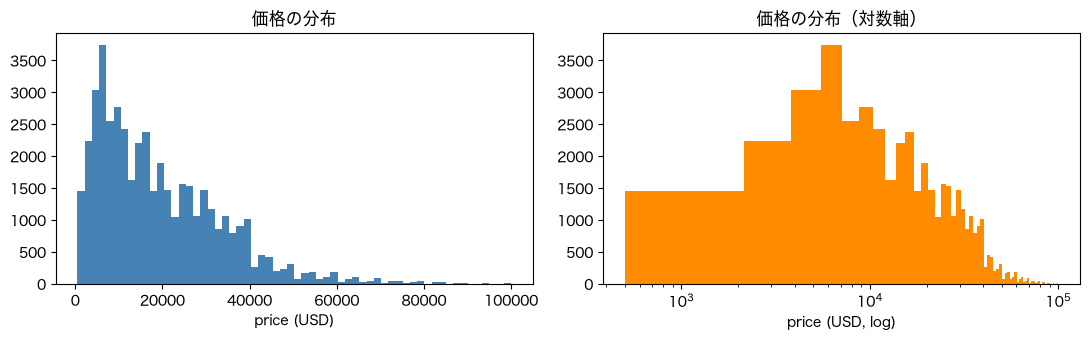

抽出 45,062 件（全体からのランダムサンプル）


In [6]:

prices = q(f"""
SELECT price FROM {{src}}
WHERE price BETWEEN {PRICE_MIN} AND {PRICE_MAX}
USING SAMPLE 50000 ROWS
""")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(prices["price"], bins=60, color="steelblue")
ax[0].set_title("価格の分布"); ax[0].set_xlabel("price (USD)")
ax[1].hist(prices["price"], bins=60, color="darkorange")
ax[1].set_xscale("log")
ax[1].set_title("価格の分布（対数軸）"); ax[1].set_xlabel("price (USD, log)")
plt.tight_layout(); plt.show()

print(f"抽出 {len(prices):,} 件（全体からのランダムサンプル）")

**読み方：** 右に裾を引いた分布です。この形のとき、価格をそのまま予測するより
`log(price)` を予測した方が精度が出ることが多いです（後で試す論点）。

## 4. メーカー別の傾向

In [7]:
makers = q(f"""
SELECT manufacturer AS メーカー,
       count(*) AS 件数,
       round(median(price)) AS 価格中央値,
       round(median(odometer)) AS 走行距離中央値
FROM {{src}}
WHERE price BETWEEN {PRICE_MIN} AND {PRICE_MAX} AND manufacturer IS NOT NULL
GROUP BY 1 ORDER BY 2 DESC LIMIT 15
""")
makers

,メーカー,件数,価格中央値,走行距離中央値
0,ford,63835,17000.0,98921.0
1,chevrolet,49513,16000.0,92000.0
2,toyota,30927,13995.0,103769.0
3,honda,19408,9250.0,113759.0
4,nissan,16949,10500.0,90222.0
5,jeep,16830,18900.0,81997.0
6,ram,16153,29995.0,87743.0
7,gmc,15219,24224.0,95000.0
8,bmw,13305,18500.0,70541.0
9,dodge,11693,12500.0,86697.0


## 5. pandas に渡す（ここで初めてメモリに載せる）

モデリングは pandas / scikit-learn でやります。
DuckDB で**必要な列・行に絞ってから** DataFrame にするのがコツです。

そして結果は **parquet** で `sampledata/processed/` に保存します。
CSV より小さく速く、列の型（数値か文字列か）も保持されます。

In [8]:
df = q(f"""
SELECT price, year, odometer, manufacturer, model, condition,
       fuel, transmission, drive, type, paint_color, state
FROM {{src}}
WHERE price BETWEEN {PRICE_MIN} AND {PRICE_MAX}
  AND year IS NOT NULL AND odometer IS NOT NULL
""")

out = PROCESSED / "vehicles_clean.parquet"
df.to_parquet(out, index=False)

print(f"{len(df):,} 行 × {df.shape[1]} 列")
print(f"保存先: {out}")
print(f"メモリ: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
df.head()

380,907 行 × 12 列
保存先: /Users/attuan/carprice/sampledata/processed/vehicles_clean.parquet
メモリ: 51 MB


,price,year,odometer,manufacturer,model,condition,fuel,transmission,drive,type,paint_color,state
0,33590,2014,57923,gmc,sierra 1500 crew cab slt,good,gas,other,NaN,pickup,white,al
1,22590,2010,71229,chevrolet,silverado 1500,good,gas,other,NaN,pickup,blue,al
2,39590,2020,19160,chevrolet,silverado 1500 crew,good,gas,other,NaN,pickup,red,al
3,30990,2017,41124,toyota,tundra double cab sr,good,gas,other,NaN,pickup,red,al
4,15000,2013,128000,ford,f-150 xlt,excellent,gas,automatic,rwd,truck,black,al


次回からは、この1行で続きが始められます。

```python
df = pd.read_parquet("../sampledata/processed/vehicles_clean.parquet")
```

`processed/` は git 管理外ですが、**このノートブックを実行すれば誰でも再生成できます。**
「データではなく手順を共有する」というのがこのリポジトリの方針です。

---

## 次にやること（候補）

- `year` と `odometer` から価格のベースラインモデルを作る（XGBoost）
- `log(price)` を予測対象にすると改善するか確かめる
- `description` から特徴量を作る（unfold 構想の検証）